**Exercício 3**


Testando com 2 dígitos
[6, 6]
  Dígitos: 2, Teste 1: 111 tentativas, 0.00000000s
[2, 9]
  Dígitos: 2, Teste 2: 113 tentativas, 0.00000000s
[0, 1]
  Dígitos: 2, Teste 3: 216 tentativas, 0.00000000s
[3, 9]
  Dígitos: 2, Teste 4: 99 tentativas, 0.00000000s
[3, 4]
  Dígitos: 2, Teste 5: 28 tentativas, 0.00000000s
[9, 4]
  Dígitos: 2, Teste 6: 141 tentativas, 0.00000000s
[9, 1]
  Dígitos: 2, Teste 7: 26 tentativas, 0.00000000s
[5, 2]
  Dígitos: 2, Teste 8: 41 tentativas, 0.00000000s
[3, 5]
  Dígitos: 2, Teste 9: 41 tentativas, 0.00000000s
[7, 9]
  Dígitos: 2, Teste 10: 326 tentativas, 0.00000000s
[9, 0]
  Dígitos: 2, Teste 11: 2 tentativas, 0.00000000s
[7, 8]
  Dígitos: 2, Teste 12: 47 tentativas, 0.00000000s
[7, 4]
  Dígitos: 2, Teste 13: 4 tentativas, 0.00000000s
[4, 4]
  Dígitos: 2, Teste 14: 62 tentativas, 0.00000000s
[1, 9]
  Dígitos: 2, Teste 15: 14 tentativas, 0.00000000s
[3, 0]
  Dígitos: 2, Teste 16: 225 tentativas, 0.00000000s
[5, 7]
  Dígitos: 2, Teste 17: 28 tentativas, 0.00000

C:\Users\André\AppData\Local\Temp\ipykernel_27992\3358517802.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_tentativas, labels=tamanhos, patch_artist=True)
C:\Users\André\AppData\Local\Temp\ipykernel_27992\3358517802.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_tempos, labels=tamanhos, patch_artist=True)


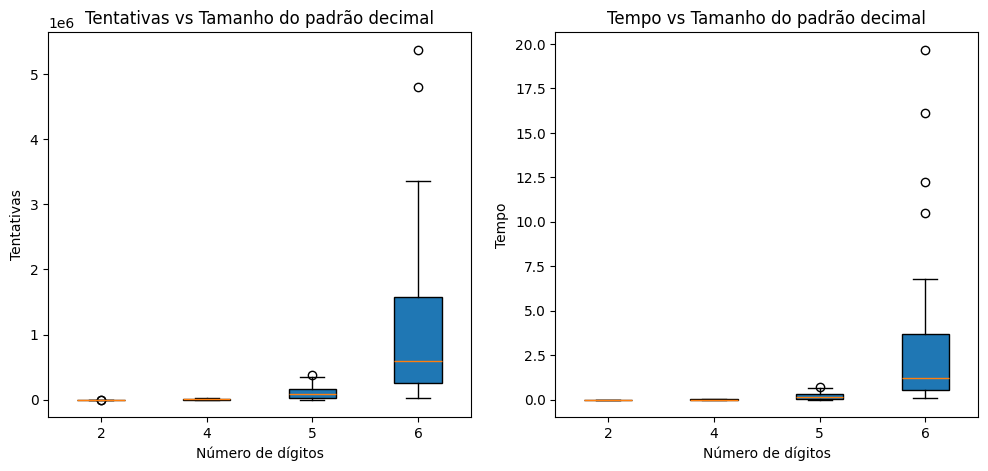

2 dígitos: Média = 95 tentativas
4 dígitos: Média = 9187 tentativas
5 dígitos: Média = 109865 tentativas
6 dígitos: Média = 1141378 tentativas


In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt


def gerar_padrao_decimal(n_digitos: int, seed=None):
    if seed is not None:
        random.seed(seed)
    return [random.randint(0, 9) for _ in range(n_digitos)]


def pesquisa_aleatoria_decimal(n_digitos, n_repeticoes=30):
    tempos, tentativas = [], []
    for r in range(n_repeticoes):
        alvo = gerar_padrao_decimal(n_digitos, seed=r)
        print(alvo)
        inicio = time.time()
        count = 0
        while True:
            guess = gerar_padrao_decimal(n_digitos)
            count += 1
            if guess == alvo:
                break
        tempo_decorrido = time.time() - inicio
        tempos.append(tempo_decorrido)
        tentativas.append(count)
        
        print(f"  Dígitos: {n_digitos}, Teste {r+1}: {count} tentativas, {tempo_decorrido:.8f}s")
        
    return tentativas, tempos


def experimento_pesquisa_aleatoria_decimal():
    tamanhos = [2, 4, 5, 6]
    resultados_tentativas = []
    resultados_tempos = []

    for n in tamanhos:
        print(f"\nTestando com {n} dígitos")
        tent, t = pesquisa_aleatoria_decimal(n)
        resultados_tentativas.append(tent)
        resultados_tempos.append(t)
        
        print(f"RESUMO {n} dígitos:")
        print(f"  Média: {np.mean(tent):.0f} tentativas")
        print(f"  Min: {np.min(tent)} tentativas")
        print(f"  Max: {np.max(tent)} tentativas")
        print(f"  Tempo médio: {np.mean(t):.4f}s")

    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.boxplot(resultados_tentativas, labels=tamanhos, patch_artist=True)
    plt.title("Tentativas vs Tamanho do padrão decimal")
    plt.xlabel("Número de dígitos")
    plt.ylabel("Tentativas")
    
    plt.subplot(1,2,2)
    plt.boxplot(resultados_tempos, labels=tamanhos, patch_artist=True)
    plt.title("Tempo vs Tamanho do padrão decimal")
    plt.xlabel("Número de dígitos")
    plt.ylabel("Tempo")
    
    plt.show()
    
    return resultados_tentativas, resultados_tempos


if __name__ == "__main__":
    resultados_tent, resultados_temp = experimento_pesquisa_aleatoria_decimal()

    tamanhos = [2, 4, 5, 6]
    for i, n in enumerate(tamanhos):
        tentativas = resultados_tent[i]
        print(f"{n} dígitos: Média = {np.mean(tentativas):.0f} tentativas")

In [37]:
def fitness_decimal(padrao, alvo):
    return np.sum(np.array(padrao) == np.array(alvo)) / len(alvo)

def mutar_decimal(padrao):
    novo = padrao.copy()
    i = random.randrange(len(novo))
    atual_digit = novo[i]
    digit = [d for d in range(10) if d != atual_digit]
    novo[i] = random.choice(digit)
    return novo

def busca_local_por_mutacao_decimal(alvo, max_iter=1000):
    atual = gerar_padrao_decimal(len(alvo))
    melhor_fit = fitness_decimal(atual, alvo)
    
    for i in range(max_iter):
        candidato = mutar_decimal(atual)
        f = fitness_decimal(candidato, alvo)
        if f > melhor_fit:
            atual, melhor_fit = candidato, f
        if melhor_fit == 1.0:
            return True, i + 1  
    return False, max_iter  

def testar_convergencia_busca_local_decimal(n_digits=20, n_testes=30):
    resultados = []
    for r in range(n_testes):
        alvo = gerar_padrao_decimal(n_digits, seed=r)
        convergiu, iteracoes = busca_local_por_mutacao_decimal(alvo)
        resultados.append((convergiu, iteracoes))
    
    n_convergiu = sum(c for c, _ in resultados)
    media_iter = np.mean([it for _, it in resultados])
    print(f"\nConvergiu: {n_convergiu}/{n_testes} ({n_convergiu/n_testes*100:.1f}%)")
    print(f"Média de iterações: {media_iter:.1f}")
    
    return resultados

if __name__ == "__main__":
    print("Teste: Busca local por mutação para padrões decimais")
    testar_convergencia_busca_local_decimal(n_digits=6, n_testes=30)

Teste: Busca local por mutação para padrões decimais

Convergiu: 30/30 (100.0%)
Média de iterações: 118.2


Teste 01: Convergiu em 390 gerações, tempo=0.263s
Teste 02: Convergiu em 403 gerações, tempo=0.271s
Teste 03: Convergiu em 383 gerações, tempo=0.259s
Teste 04: Convergiu em 367 gerações, tempo=0.248s
Teste 05: Convergiu em 430 gerações, tempo=0.304s
Teste 06: Convergiu em 331 gerações, tempo=0.223s
Teste 07: Convergiu em 352 gerações, tempo=0.237s
Teste 08: Convergiu em 379 gerações, tempo=0.254s
Teste 09: Convergiu em 344 gerações, tempo=0.230s
Teste 10: Convergiu em 312 gerações, tempo=0.208s
Teste 11: Convergiu em 367 gerações, tempo=0.246s
Teste 12: Convergiu em 381 gerações, tempo=0.253s
Teste 13: Convergiu em 368 gerações, tempo=0.248s
Teste 14: Convergiu em 391 gerações, tempo=0.262s
Teste 15: Convergiu em 396 gerações, tempo=0.269s
Teste 16: Convergiu em 322 gerações, tempo=0.219s
Teste 17: Convergiu em 349 gerações, tempo=0.237s
Teste 18: Convergiu em 336 gerações, tempo=0.226s
Teste 19: Convergiu em 346 gerações, tempo=0.232s
Teste 20: Convergiu em 402 gerações, tempo=0.268s


C:\Users\costa\AppData\Local\Temp\ipykernel_33072\495297903.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_geracoes, labels=[f'{n_digitos} dígitos'], patch_artist=True)
C:\Users\costa\AppData\Local\Temp\ipykernel_33072\495297903.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tempos, labels=[f'{n_digitos} dígitos'], patch_artist=True)


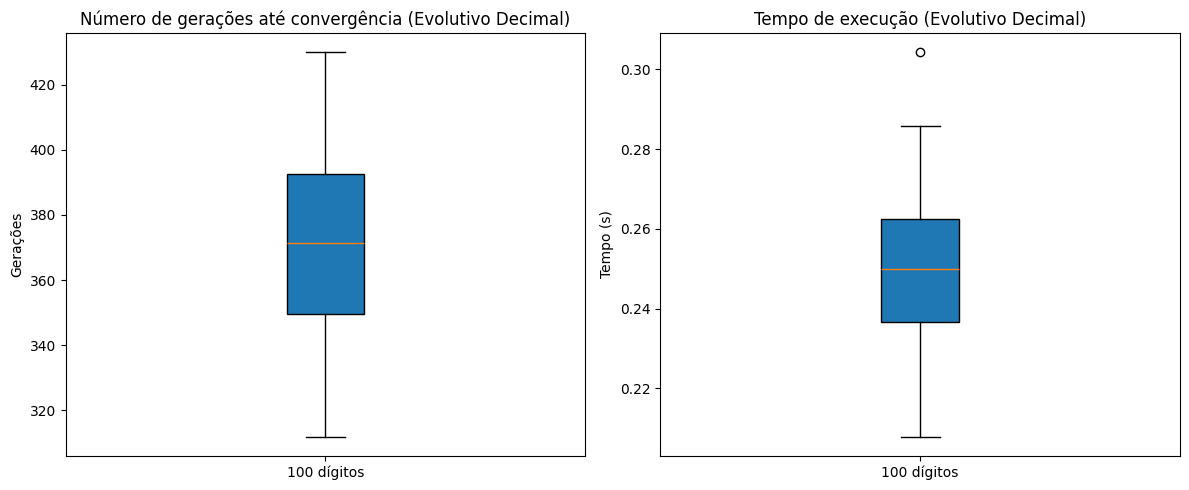

Média de gerações: 372.5
Média de tempo: 0.251s


In [38]:
def evolutivo_decimal_generations(alvo, tam_pop=100, elite=0.3, max_gen=1000):
    n_elite = int(tam_pop * elite)

    pop = [gerar_padrao_decimal(len(alvo)) for _ in range(tam_pop)]
    historico = []

    for gen in range(1, max_gen+1):
        fits = [fitness_decimal(ind, alvo) for ind in pop]
        #print(f"g {(gen)} {np.mean(fits):.1f}")
        melhor_fit = max(fits)
        historico.append(melhor_fit)

        if melhor_fit == 1.0:
            return melhor_fit, gen, historico  

        indices = np.argsort(fits)[::-1]
        elite_pop = [pop[i] for i in indices[:n_elite]]

        novos = elite_pop.copy()
        while len(novos) < tam_pop:
            pai = random.choice(elite_pop)
            filho = mutar_decimal(pai)
            novos.append(filho)
        pop = novos

    return melhor_fit, max_gen, historico

def experimento_evolutivo_decimal_generations(n_digitos=8, n_repeticoes=30):
    resultados_geracoes = []
    tempos = []

    for r in range(n_repeticoes):
        alvo = gerar_padrao_decimal(n_digitos, seed=r)
        inicio = time.time()
        _, geracoes, _ = evolutivo_decimal_generations(alvo)
        tempo_decorrido = time.time() - inicio
        tempos.append(tempo_decorrido)
        resultados_geracoes.append(geracoes)
        print(f"Teste {r+1:02d}: Convergiu em {geracoes} gerações, tempo={tempo_decorrido:.3f}s")

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.boxplot(resultados_geracoes, labels=[f'{n_digitos} dígitos'], patch_artist=True)
    plt.title("Número de gerações até convergência (Evolutivo Decimal)")
    plt.ylabel("Gerações")

    plt.subplot(1,2,2)
    plt.boxplot(tempos, labels=[f'{n_digitos} dígitos'], patch_artist=True)
    plt.title("Tempo de execução (Evolutivo Decimal)")
    plt.ylabel("Tempo (s)")

    plt.tight_layout()
    plt.show()

    print(f"Média de gerações: {np.mean(resultados_geracoes):.1f}")
    print(f"Média de tempo: {np.mean(tempos):.3f}s")

    return resultados_geracoes, tempos


if __name__ == "__main__":
    resultados_ger, tempos = experimento_evolutivo_decimal_generations(n_digitos=100, n_repeticoes=30)

Convergiu na geração 6
Convergiu Teste 01: Alvo=6 dígitos, gerações=6, tempo=0.002s
Convergiu na geração 6
Convergiu Teste 02: Alvo=6 dígitos, gerações=6, tempo=0.003s
Convergiu na geração 6
Convergiu Teste 03: Alvo=6 dígitos, gerações=6, tempo=0.002s
Convergiu na geração 6
Convergiu Teste 04: Alvo=6 dígitos, gerações=6, tempo=0.002s
Convergiu na geração 7
Convergiu Teste 05: Alvo=6 dígitos, gerações=7, tempo=0.002s
Convergiu na geração 5
Convergiu Teste 06: Alvo=6 dígitos, gerações=5, tempo=0.002s
Convergiu na geração 7
Convergiu Teste 07: Alvo=6 dígitos, gerações=7, tempo=0.002s
Convergiu na geração 5
Convergiu Teste 08: Alvo=6 dígitos, gerações=5, tempo=0.002s
Convergiu na geração 6
Convergiu Teste 09: Alvo=6 dígitos, gerações=6, tempo=0.003s
Convergiu na geração 6
Convergiu Teste 10: Alvo=6 dígitos, gerações=6, tempo=0.003s
Convergiu na geração 6
Convergiu Teste 11: Alvo=6 dígitos, gerações=6, tempo=0.003s
Convergiu na geração 6
Convergiu Teste 12: Alvo=6 dígitos, gerações=6, tempo

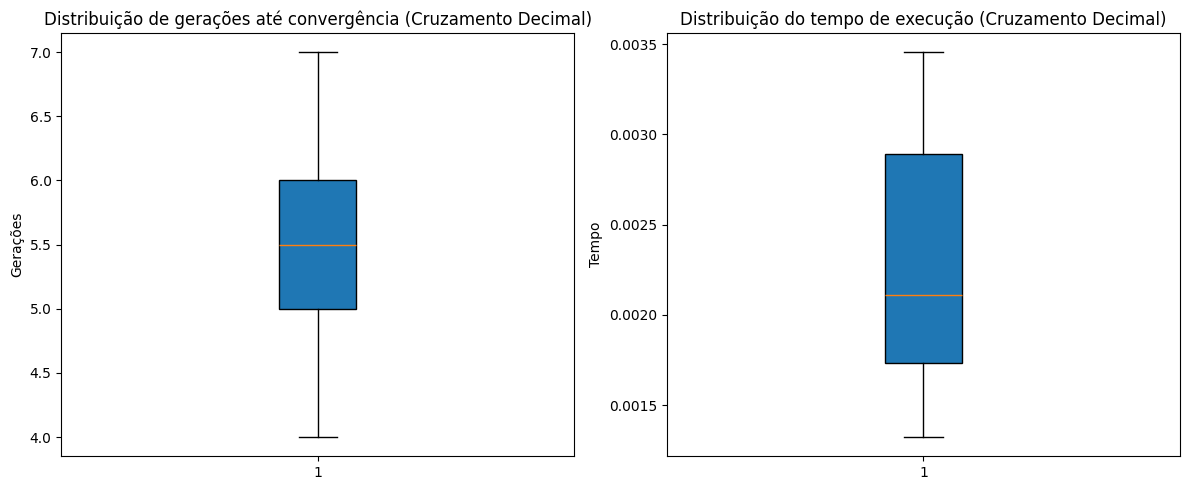

In [39]:
def cruzamento_decimal(pai1, pai2):
    n = len(pai1)
    ponto = random.randint(1, n-1)
    filho = pai1[:ponto] + pai2[ponto:]
    return filho


def algoritmo_genetico_decimal(alvo, pop_size=100, taxa_selecao=0.3, max_geracoes=1000):
    n_dig = len(alvo)
    populacao = [gerar_padrao_decimal(n_dig) for _ in range(pop_size)]
    historico_melhor = []
    geracao = 0

    while geracao < max_geracoes:
        geracao += 1
        fit_values = [fitness_decimal(ind, alvo) for ind in populacao]
        idx_melhor = np.argmax(fit_values)
        fit_atual = fit_values[idx_melhor]
        historico_melhor.append(fit_atual)

        if populacao[idx_melhor] == alvo:
            print(f"Convergiu na geração {geracao}")
            return populacao[idx_melhor], geracao, True, historico_melhor

        n_selecionados = int(pop_size * taxa_selecao)
        idx_ordenados = np.argsort(fit_values)[::-1]
        melhores = [populacao[i] for i in idx_ordenados[:n_selecionados]]

        nova_pop = melhores.copy()
        while len(nova_pop) < pop_size:
            pai1, pai2 = random.sample(melhores, 2)
            filho = cruzamento_decimal(pai1, pai2)
            nova_pop.append(filho)

        populacao = nova_pop

    print(f"Não convergiu após {max_geracoes} gerações (melhor fitness={fit_atual:.3f})")
    return populacao[idx_melhor], geracao, False, historico_melhor


def testar_algoritmo_genetico_decimal(n_testes=30, n_digitos=6, pop_size=100, max_geracoes=1000):
    resultados = []
    tempos = []

    for r in range(n_testes):
        alvo = gerar_padrao_decimal(n_digitos, seed=r)
        inicio = time.time()
        melhor, geracoes, convergiu, hist = algoritmo_genetico_decimal(
            alvo, pop_size=pop_size, max_geracoes=max_geracoes)
        tempo_decorrido = time.time() - inicio
        resultados.append((convergiu, geracoes))
        tempos.append(tempo_decorrido)
        status = "Convergiu" if convergiu else "Não convergiu"
        print(f"{status} Teste {r+1:02d}: Alvo={n_digitos} dígitos, gerações={geracoes}, tempo={tempo_decorrido:.3f}s")

    n_convergiu = sum(c for c, _ in resultados)
    media_geracoes = np.mean([g for _, g in resultados])
    media_tempo = np.mean(tempos)

    print(f"\nConvergiu: {n_convergiu}/{n_testes} ({n_convergiu/n_testes*100:.1f}%)")
    print(f"Média de gerações: {media_geracoes:.1f}")
    print(f"Média de tempo: {media_tempo:.3f}s")

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.boxplot([g for _, g in resultados], vert=True, patch_artist=True)
    plt.title("Distribuição de gerações até convergência (Cruzamento Decimal)")
    plt.ylabel("Gerações")

    plt.subplot(1,2,2)
    plt.boxplot(tempos, vert=True, patch_artist=True)
    plt.title("Distribuição do tempo de execução (Cruzamento Decimal)")
    plt.ylabel("Tempo")

    plt.tight_layout()
    plt.show()

    return resultados, tempos


if __name__ == "__main__":
    resultados, tempos = testar_algoritmo_genetico_decimal(
        n_testes=30, n_digitos=6, pop_size=100, max_geracoes=1000)

Para o Exercício 3, as diferenças em relação aos exercícios anteriores foram as seguintes:

- A função para gerar um padrão agora produz sequências de dígitos decimais (0-9) em vez de bits (0-1), tendo um tamanho fixo tal como no exercicio 1.

- A função de avaliação (fitness) foi adaptada para comparar padrões de dígitos decimais, calculando a percentagem de posições com valores idênticos entre o padrão candidato e o alvo. Ao contrário do Exercício 2, não há penalização por diferença de tamanho, assumindo que ambos os padrões têm dimensões iguais.

- A função de mutação foi modificada para operar sobre dígitos decimais. Em vez de simplesmente inverter um bit, esta função seleciona aleatoriamente uma posição no padrão e substitui o dígito nessa posição por um valor diferente do atual (garantindo sempre uma alteração efetiva).

- A função de cruzamento mantém a mesma lógica dos exercícios anteriores, combinando dois pais através de um ponto de corte aleatório. No entanto, agora trabalha com arrays de dígitos decimais em vez de bits, criando um filho que herda a primeira parte de um pai e a segunda parte do outro pai.